In [15]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from pathlib import Path

import clean_utility_survey as cus
import utility_survey_analysis as usa

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Data Cleaning

In [16]:
# ---- Scenario config: the only cell to change for a new scenario ----
root = Path().resolve().parent.parent
csv_path = root / "human_data" / "moral_comp_exp4" / \
    "Moral+Annotator+-+utility+validation+test+-+brother+1+-+zm_September+30,+2026_10.42.csv"
output_path = Path("pilot_brother1_clean.csv")

# Correct answer for every attention check (ImportId -> option text, or a rule on the slider value).
# Run the next cell to list this survey's attention checks and their ImportIds.
ATTENTION_ANSWERS = {
    "QID92":    "Extremely worrying messages about harming himself and feeling hopeless",
    "QID150_1": lambda v: v != -100,   # bomb in community center: any value except -100
    "QID151_1": lambda v: v == -100,   # Sally crushed by trolley: exactly -100
    "QID99":    "My parents become aware that my brother is feeling hopeless and talking about harming himself",
    "QID152":   "knew/intend/cause",
    "QID154":   "-100 is equal to very painful death(s) for the character/group.",
    "QID122":   "My brother feels exposed and betrayed",
    "QID153":   "knew/intend/cause",
    "QID155":   "+100 is equal to perfect peace and happiness for the character/group.",
}

# Hard-coded exclusions, by Qualtrics response ID
EXCLUDED_IDS = [
    "R_11gEtdpv1iRjiCR",   # Subject 0
    "R_7ZQPyqBlZ7Vr0Ng",   # Subject 6 (off-topic sentience answer)
]

MIN_ATTENTION_CORRECT = 6

In [17]:
# Check the detected survey layout (characters, outcomes, attention checks)
df, codebook = cus.load_qualtrics(csv_path)
structure = cus.detect_structure(codebook)
cus.describe_structure(structure, codebook)

Characters: 4
  char_1: my parents
  char_2: my younger brother
  char_3: my brother's chat correspondents
  char_4: I
Outcomes: 6
  outcome_1: My parents become aware that my brother is feeling hopeless and talking about harming himself
  outcome_2: My parents become alarmed and distressed
  outcome_3: My brother's privacy is violated
  outcome_4: My brother feels exposed and betrayed
  outcome_5: My parents are able to step in to support my brother
  outcome_6: I feel guilty and conflicted
Causal questions per outcome: 3
Attention checks: 9
  attention_1 (QID92): What did the narrator find on their brother's laptop after logging in?
  attention_2 (QID150_1): Suppose a person detonates a bomb in the middle of a community center that is filled with 
  attention_3 (QID151_1): If Sally is crushed to death by a trolley someone intentionally diverted to run them over,
  attention_4 (QID99): Which outcome below are you considering?
  attention_5 (QID152): What properties of the scenario wer

In [18]:
result = cus.clean_survey(csv_path, ATTENTION_ANSWERS,
                          excluded_ids=EXCLUDED_IDS,
                          min_attention_correct=MIN_ATTENTION_CORRECT)
clean = result.clean

print("Exclusions:")
print(result.exclusions["reason"].value_counts().to_string())

# Number and percentage of participants who missed each attention check
missed = ~result.attention_checks
missed_summary = pd.DataFrame({"missed": missed.sum(),
                               "missed_%": (100 * missed.mean()).round(1)})
print(f"\nAttention checks missed (before the cutoff, n={len(missed)}):")
print(missed_summary.to_string())

clean.shape

Exclusions:
reason
not finished                             11
sentience blank                           5
manual exclusion                          2
not sentient                              1
fewer than 6 attention checks correct     1

Attention checks missed (before the cutoff, n=15):
          missed  missed_%
QID92          0       0.0
QID150_1       8      53.3
QID151_1       2      13.3
QID99          0       0.0
QID152         3      20.0
QID154         2      13.3
QID122         0       0.0
QID153         5      33.3
QID155         4      26.7


(14, 67)

In [19]:
clean.to_csv(output_path, index=False)

### Descriptive Statistics

In [20]:
char_labels = result.structure["char_labels"]
print(usa.survey_dims(clean))
print(usa.char_names(clean, char_labels))

{'n_chars': 4, 'n_outcomes': 6}
['my parents', 'my younger brother', "my brother's chat correspondents", 'I']


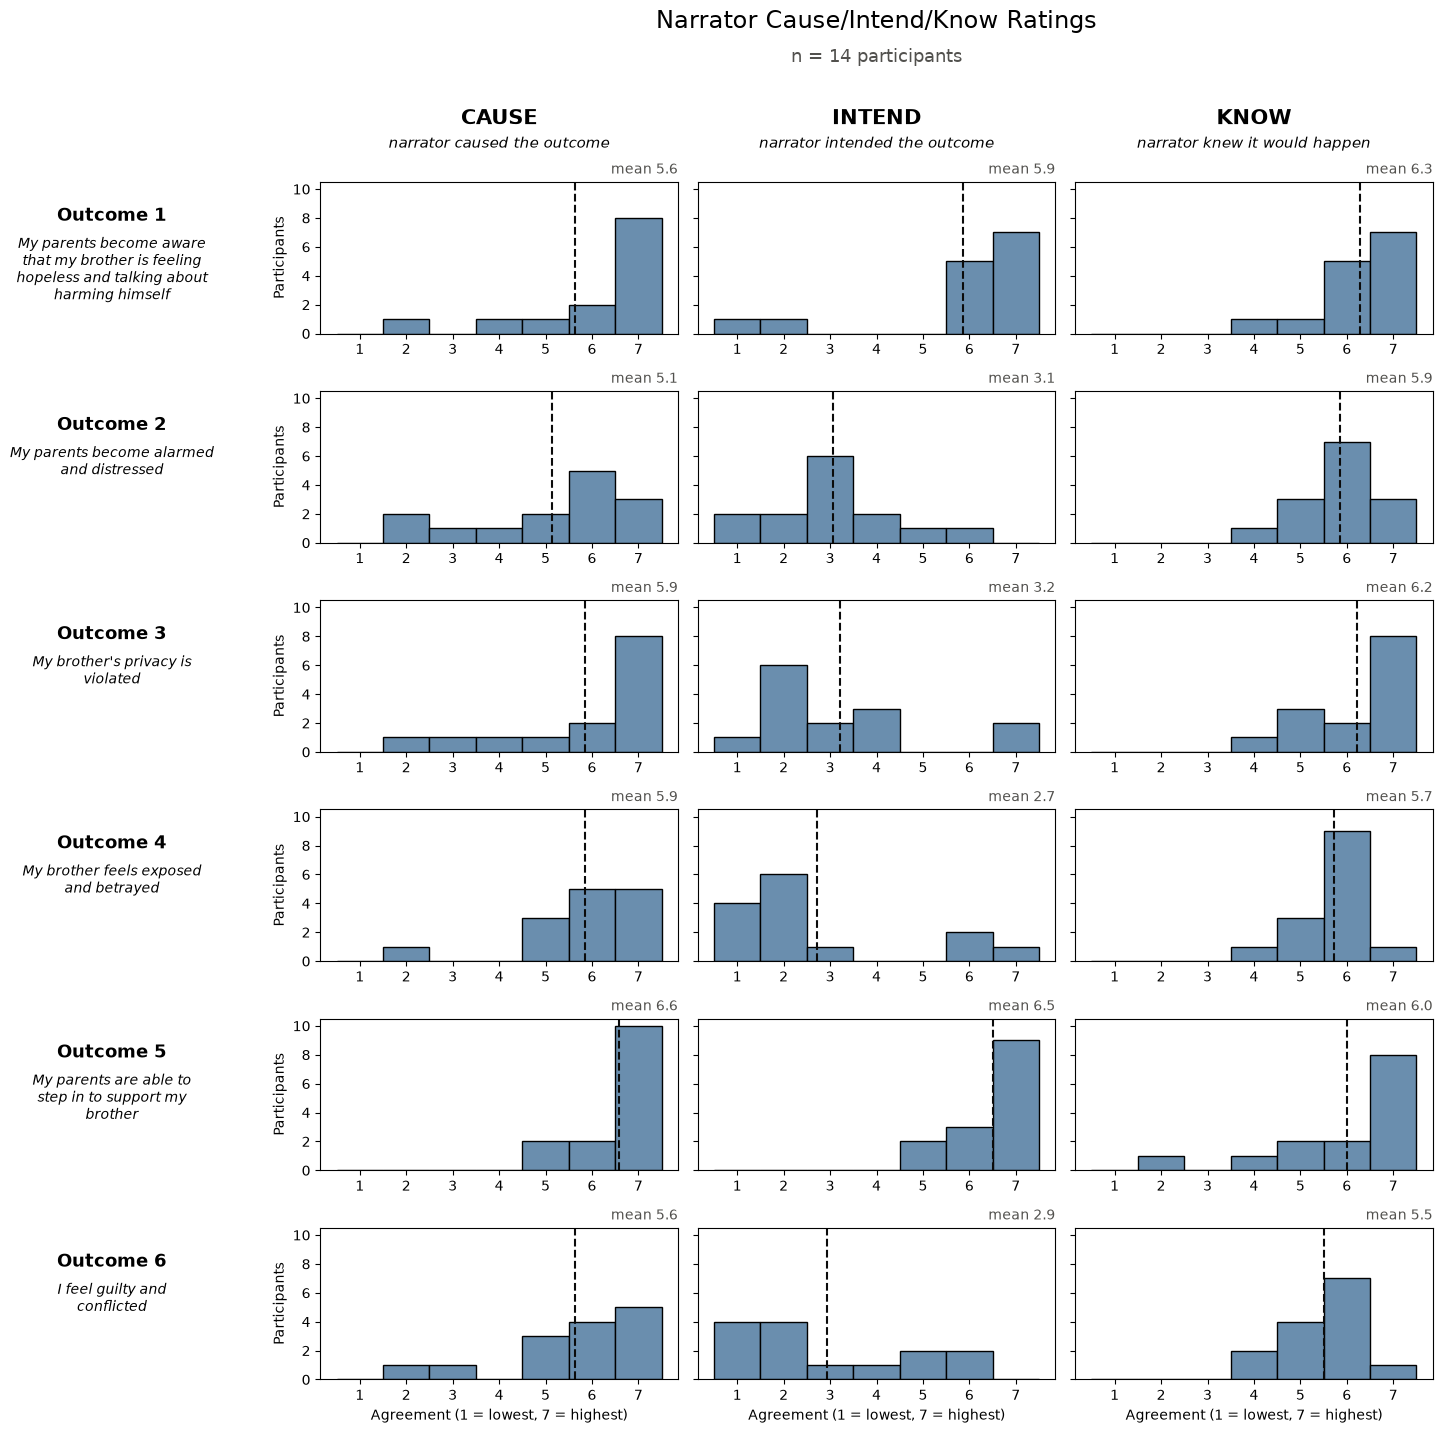

In [21]:
# CIK links: narrator Cause / Intend / Know ratings for each outcome
outcome_labels = result.structure["outcome_labels"]
fig_cik = usa.plot_cik(clean, outcome_labels)

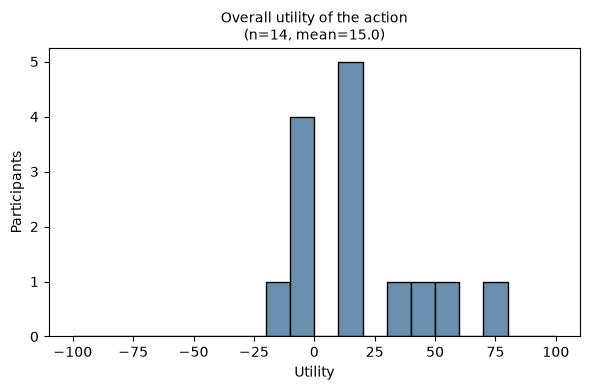

In [23]:
# Overall utility of the action
fig_overall = usa.plot_overall_utility(clean)

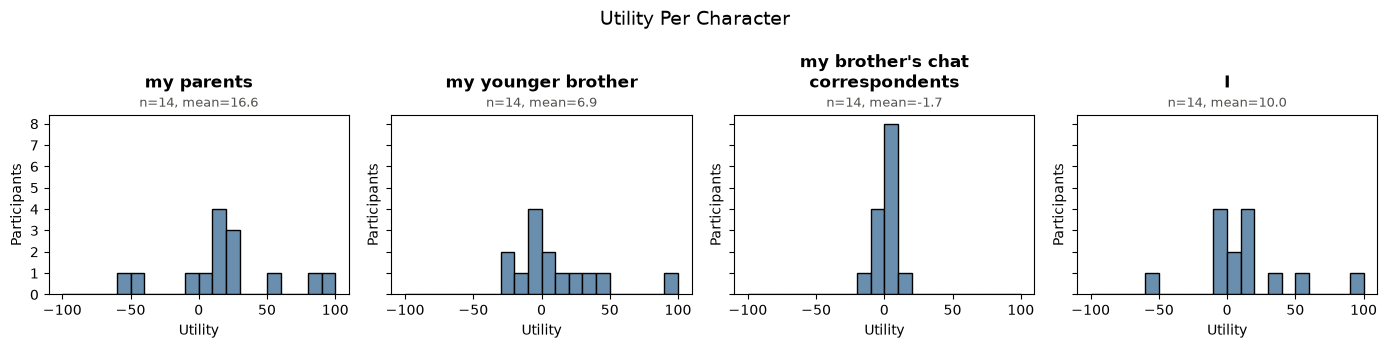

In [24]:
# Per-character utility of the action (not per outcome)
fig_char = usa.plot_char_utilities(clean, char_labels)

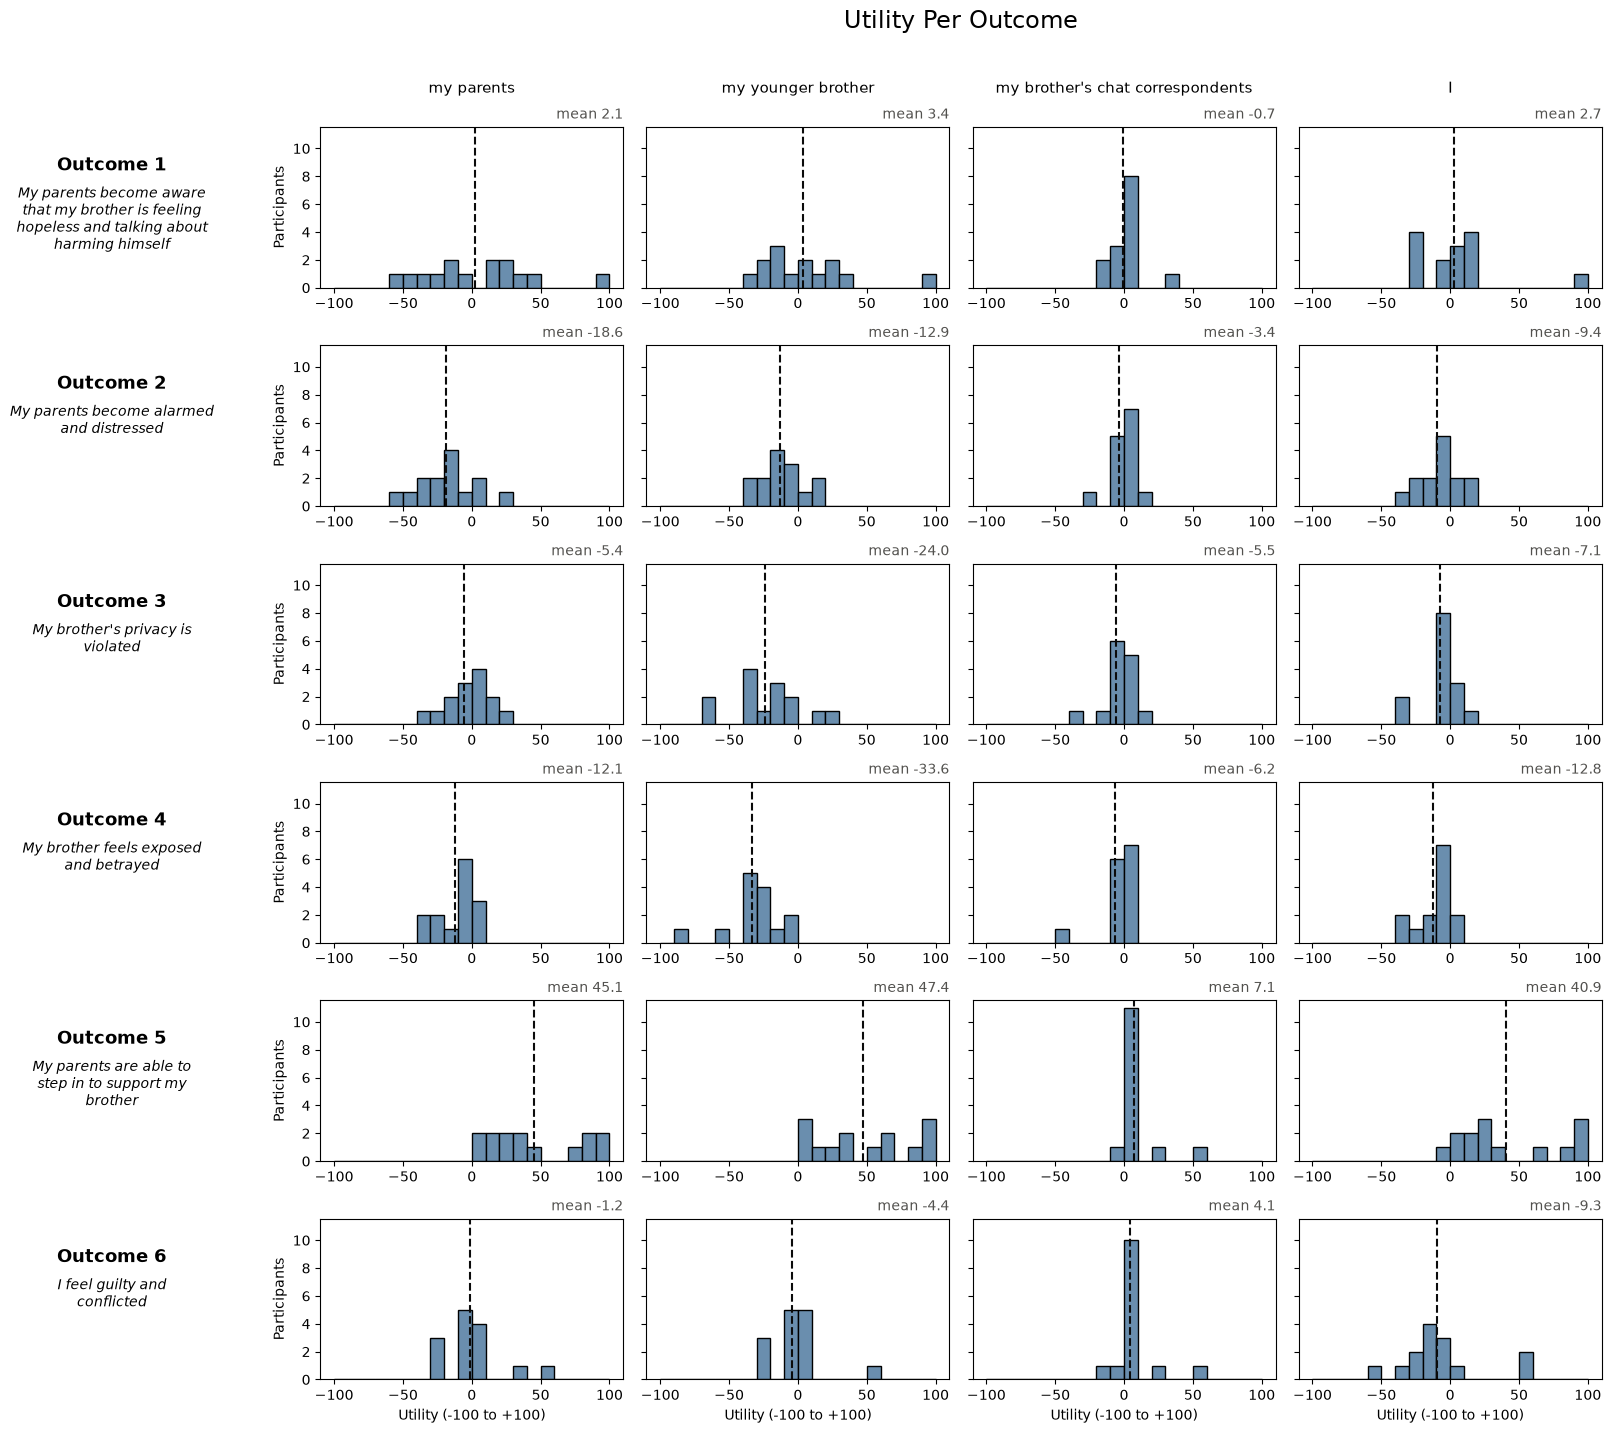

In [25]:
# For each outcome: per-character utility
fig_outcome_char = usa.plot_outcome_char_utilities(clean, char_labels, outcome_labels)

### Utility Aggregations

(a) Sum of a character's per-outcome utilities vs. that character's rated utility  
(b) Sum of all per-outcome, per-character utilities vs. the overall utility  
(c) Sum of the per-character utilities vs. the overall utility

In [26]:
# Per-participant sums
agg = usa.utility_aggregations(clean)
agg

,Subject,overall_utility,char_1_utility,char_1_outcome_sum,char_2_utility,char_2_outcome_sum,char_3_utility,char_3_outcome_sum,char_4_utility,char_4_outcome_sum,outcome_utility_sum,char_utility_sum
0,0,19.0,25.0,67.0,45.0,89.0,-10.0,12.0,15.0,28.0,196.0,75.0
1,1,10.0,17.0,57.0,-10.0,11.0,0.0,-10.0,13.0,11.0,69.0,20.0
2,2,35.0,20.0,-35.0,30.0,0.0,-5.0,-20.0,10.0,-20.0,-75.0,55.0
3,3,-14.0,3.0,-60.0,-30.0,-130.0,0.0,0.0,-10.0,-89.0,-279.0,-37.0
4,4,-10.0,-10.0,-124.0,-10.0,-128.0,0.0,0.0,0.0,-8.0,-260.0,-20.0
5,5,40.0,54.0,-4.0,-20.0,-166.0,0.0,0.0,35.0,-83.0,-253.0,69.0
6,6,-5.0,-60.0,-110.0,0.0,-70.0,-10.0,-40.0,-60.0,-115.0,-335.0,-130.0
7,7,70.0,80.0,18.0,-5.0,-7.0,5.0,18.0,50.0,11.0,40.0,130.0
8,8,50.0,-47.0,11.0,2.0,-84.0,-12.0,-87.0,0.0,131.0,-29.0,-57.0
9,9,10.0,10.0,25.0,10.0,23.0,3.0,8.0,10.0,21.0,77.0,33.0


In [27]:
# How well each summed utility recovers the rated one
pairs = usa.comparison_pairs(clean, char_labels)
usa.aggregation_summary(agg, pairs)

,comparison,rated_mean,summed_mean,mean_diff (summed - rated),mean_abs_diff,pearson_r,same_sign_%
0,(a) my parents: sum over outcomes vs. rated ch...,16.57,9.79,-6.79,54.64,0.69,64.29
1,(a) my younger brother: sum over outcomes vs. ...,6.93,-24.21,-31.14,58.43,0.85,64.29
2,(a) my brother's chat correspondents: sum over...,-1.71,-4.64,-2.93,18.64,0.75,71.43
3,(a) I: sum over outcomes vs. rated character u...,10.00,5.00,-5.00,49.43,0.71,71.43
4,(b) sum over outcomes and characters vs. overa...,15.00,-14.07,-29.07,188.64,-0.04,64.29
5,(c) sum of character utilities vs. overall uti...,15.00,31.79,16.79,61.07,0.14,78.57


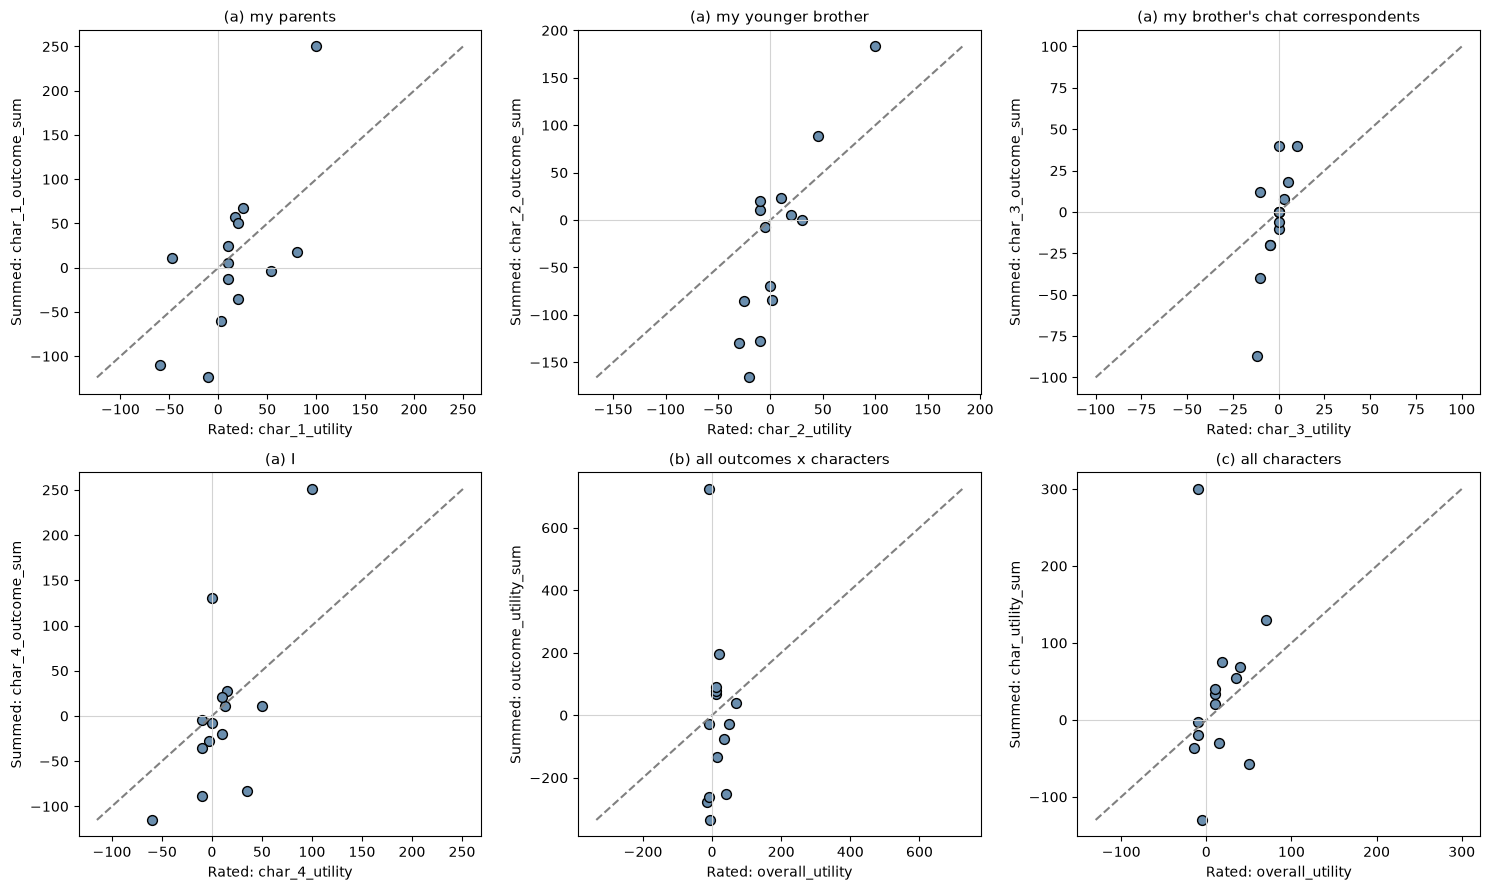

In [28]:
# Summed vs. rated utility per participant (dashed line = perfect recovery)
fig_agg = usa.plot_aggregations(agg, pairs)